# Phase A.3 - Analyse du Texte

Ce notebook contient les analyses suivantes:
1. Les avis négatifs sont-ils plus longs que les avis positifs?
2. Longueur moyenne des reviews par classe de note (1 → 5)
3. Comparaison des vocabulaires dans les avis négatifs et positifs (TF-IDF)

## 0. Import et chargement des données

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# Charger les données
DATA_DIR = Path('../../data')

def load_json_lines(file_path, n_lines=None):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if n_lines and i >= n_lines:
                break
            data.append(json.loads(line))
            if (i + 1) % 100000 == 0:
                print(f"  Chargé {i + 1:,} lignes...")
    return pd.DataFrame(data)

SAMPLE_SIZE = None  # Utilisez un échantillon pour tester (ex: 100000)

print("Chargement des reviews...")
df_reviews = load_json_lines('./raw/yelp_academic_reviews4students.jsonl', n_lines=SAMPLE_SIZE)
print(f"✓ {len(df_reviews):,} reviews chargées")

Chargement des reviews...
  Chargé 100,000 lignes...
  Chargé 200,000 lignes...
  Chargé 300,000 lignes...
  Chargé 400,000 lignes...
  Chargé 500,000 lignes...
  Chargé 600,000 lignes...
  Chargé 700,000 lignes...
  Chargé 800,000 lignes...
  Chargé 900,000 lignes...
  Chargé 1,000,000 lignes...
✓ 1,000,000 reviews chargées


In [8]:
# Préparer les données
df_reviews['text_length'] = df_reviews['text'].str.len()
df_reviews['word_count'] = df_reviews['text'].str.split().str.len()

# Créer la colonne polarité
def get_polarity(rating):
    if rating > 3:
        return 'positif'
    elif rating < 3:
        return 'négatif'
    else:
        return 'neutre'

df_reviews['polarity'] = df_reviews['stars'].apply(get_polarity)

print("Données préparées avec succès")
print(f"Colonnes disponibles: {df_reviews.columns.tolist()}")

Données préparées avec succès
Colonnes disponibles: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'text_length', 'word_count', 'polarity']


## 1. Longueur des reviews par classe de note

In [9]:
# Statistiques de longueur par note
length_by_stars = df_reviews.groupby('stars').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std'],
    'review_id': 'count'
}).round(2)

length_by_stars.columns = ['Longueur_moy', 'Longueur_med', 'Longueur_std',
                           'Nb_mots_moy', 'Nb_mots_med', 'Nb_mots_std', 'Nb_reviews']

print("=" * 80)
print("STATISTIQUES DE LONGUEUR PAR NOTE (1-5 étoiles)")
print("=" * 80)
print(length_by_stars)
print("=" * 80)

STATISTIQUES DE LONGUEUR PAR NOTE (1-5 étoiles)
       Longueur_moy  Longueur_med  Longueur_std  Nb_mots_moy  Nb_mots_med  \
stars                                                                       
1            713.22         513.0        660.02       133.87         96.0   
2            726.51         544.0        626.08       135.39        101.0   
3            668.44         508.0        565.67       124.05         95.0   
4            588.45         438.0        512.04       108.21         81.0   
5            462.94         331.0        428.07        84.49         60.0   

       Nb_mots_std  Nb_reviews  
stars                           
1           124.34      153057  
2           116.78       77630  
3           104.64       98714  
4            94.11      207953  
5            78.52      462646  


In [10]:
# Statistiques par polarité
length_by_polarity = df_reviews.groupby('polarity').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std'],
    'review_id': 'count'
}).round(2)

print("\n" + "=" * 80)
print("STATISTIQUES DE LONGUEUR PAR POLARITÉ")
print("=" * 80)
print(length_by_polarity)
print("=" * 80)


STATISTIQUES DE LONGUEUR PAR POLARITÉ
         text_length                word_count                review_id
                mean median     std       mean median     std     count
polarity                                                               
neutre        668.44  508.0  565.67     124.05   95.0  104.64     98714
négatif       717.69  523.0  648.83     134.38   98.0  121.85    230687
positif       501.86  360.0  459.45      91.84   66.0   84.38    670599


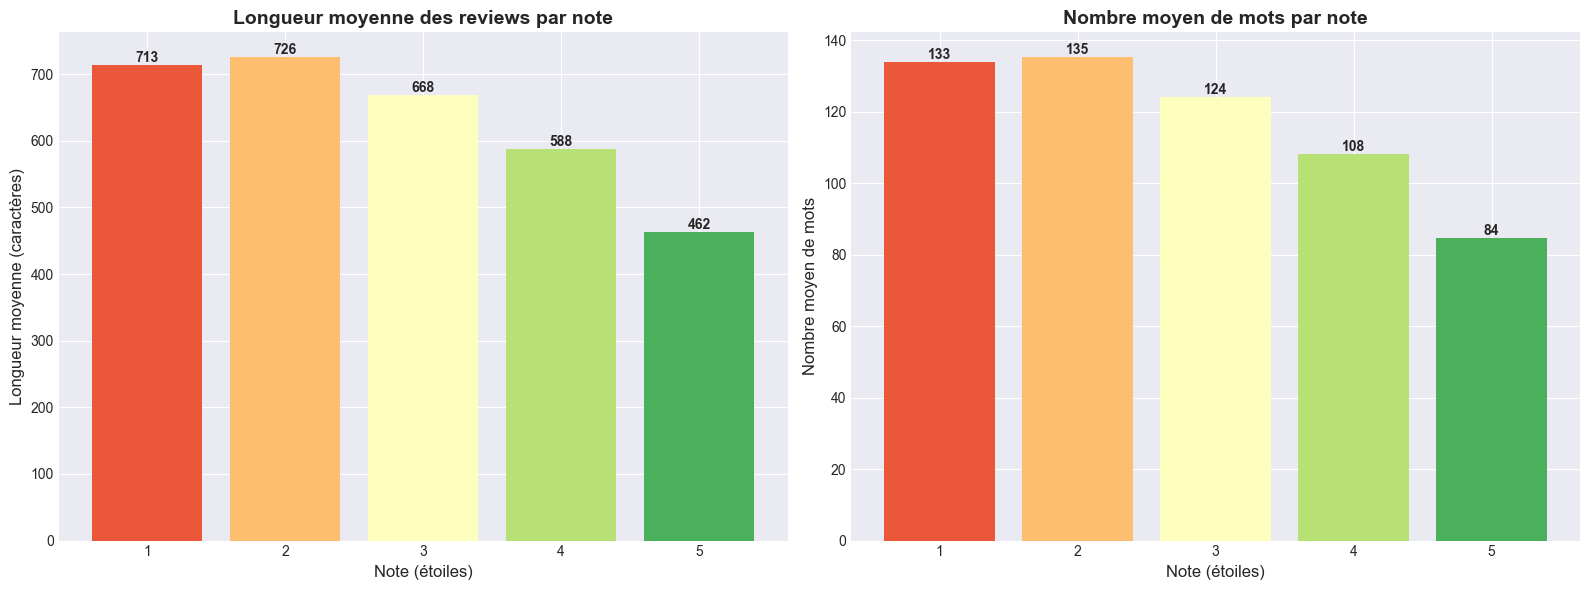

In [15]:
# Visualisation 1: Bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Longueur moyenne par note (en caractères)
avg_length = df_reviews.groupby('stars')['text_length'].mean()
bars1 = ax1.bar(avg_length.index, avg_length.values, 
               color=sns.color_palette("RdYlGn", len(avg_length)))
ax1.set_xlabel('Note (étoiles)', fontsize=12)
ax1.set_ylabel('Longueur moyenne (caractères)', fontsize=12)
ax1.set_title('Longueur moyenne des reviews par note', fontsize=14, fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Nombre de mots moyen par note
avg_words = df_reviews.groupby('stars')['word_count'].mean()
bars2 = ax2.bar(avg_words.index, avg_words.values,
               color=sns.color_palette("RdYlGn", len(avg_words)))
ax2.set_xlabel('Note (étoiles)', fontsize=12)
ax2.set_ylabel('Nombre moyen de mots', fontsize=12)
ax2.set_title('Nombre moyen de mots par note', fontsize=14, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4, 5])

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Est-ce que les avis négatifs sont plus longs ?

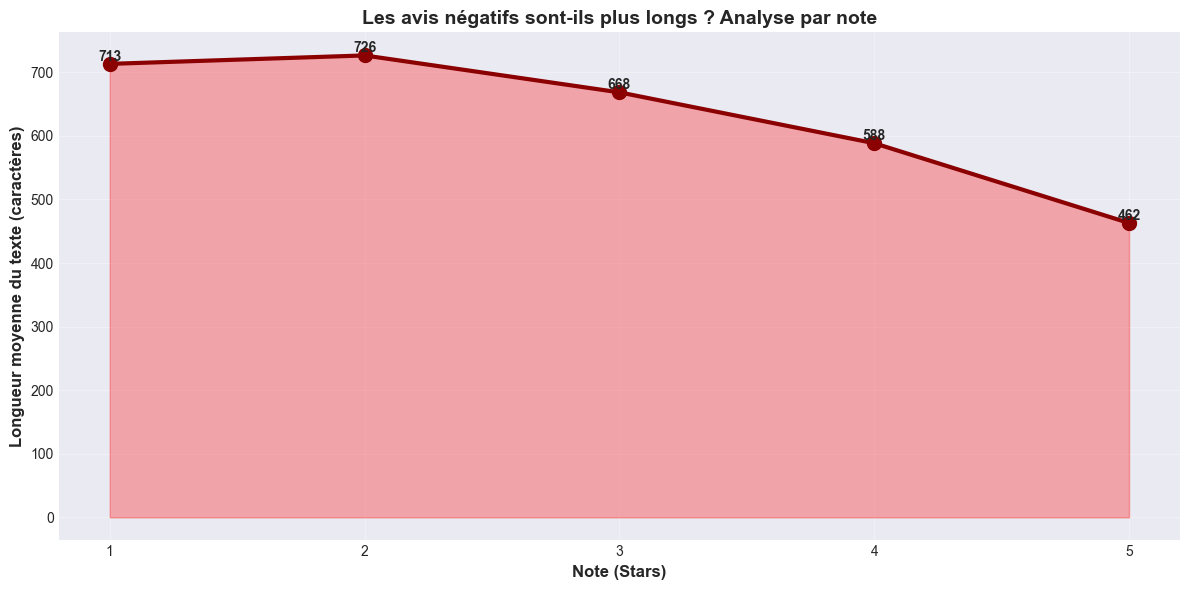

✓ Longueur moyenne des avis par note


In [26]:
# Longueur moyenne des avis par note
fig, ax = plt.subplots(figsize=(12, 6))

text_length_by_rating = df_reviews.groupby('stars')['text_length'].mean()
ax.plot(text_length_by_rating.index, text_length_by_rating.values, marker='o', linewidth=3, markersize=10, color='darkred')
ax.fill_between(text_length_by_rating.index, text_length_by_rating.values, alpha=0.3, color='red')
ax.set_xlabel('Note (Stars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Longueur moyenne du texte (caractères)', fontsize=12, fontweight='bold')
ax.set_title('Les avis négatifs sont-ils plus longs ? Analyse par note', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks([1, 2, 3, 4, 5])

# Ajouter les valeurs sur chaque point
for idx, val in text_length_by_rating.items():
    ax.text(idx, val, f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✓ Longueur moyenne des avis par note")

In [ ]:
# Test statistique: Les avis négatifs sont-ils plus longs?
from scipy.stats import mannwhitneyu, kruskal

negative_lengths = df_reviews[df_reviews['polarity'] == 'négatif']['word_count']
positive_lengths = df_reviews[df_reviews['polarity'] == 'positif']['word_count']
neutral_lengths = df_reviews[df_reviews['polarity'] == 'neutre']['word_count']

print("=" * 80)
print("COMPARAISON: AVIS NÉGATIFS vs POSITIFS")
print("=" * 80)
print(f"Moyenne négatifs: {negative_lengths.mean():.1f} mots")
print(f"Moyenne positifs: {positive_lengths.mean():.1f} mots")
print(f"Moyenne neutres:  {neutral_lengths.mean():.1f} mots")

statistic, p_value = mannwhitneyu(negative_lengths, positive_lengths, alternative='two-sided')
print(f"\nTest de Mann-Whitney U (négatifs vs positifs):")
print(f"Statistique: {statistic:.2f}")
print(f"P-value: {p_value:.2e}")

if p_value < 0.05:
    print("\n→ Différence SIGNIFICATIVE")
    if negative_lengths.mean() > positive_lengths.mean():
        diff = negative_lengths.mean() - positive_lengths.mean()
        pct = (diff / positive_lengths.mean()) * 100
        print(f"→ Les avis NÉGATIFS sont PLUS LONGS")
        print(f"→ Différence: +{diff:.1f} mots ({pct:.1f}% plus long)")
    else:
        print(f"→ Les avis POSITIFS sont PLUS LONGS")
else:
    print("\n→ Pas de différence significative")

# Test de Kruskal-Wallis pour comparer les 3 groupes
statistic_kw, p_value_kw = kruskal(negative_lengths, neutral_lengths, positive_lengths)
print(f"\nTest de Kruskal-Wallis (3 groupes):")
print(f"Statistique: {statistic_kw:.2f}")
print(f"P-value: {p_value_kw:.2e}")
print("=" * 80)

COMPARAISON: AVIS NÉGATIFS vs POSITIFS
Moyenne négatifs: 134.4 mots
Moyenne positifs: 91.8 mots
Moyenne neutres:  124.1 mots

Test de Mann-Whitney U (négatifs vs positifs):
Statistique: 97055998264.50
P-value: 0.00e+00

→ Différence SIGNIFICATIVE
→ Les avis NÉGATIFS sont PLUS LONGS
→ Différence: +42.5 mots (46.3% plus long)

Test de Kruskal-Wallis (3 groupes):
Statistique: 40668.86
P-value: 0.00e+00


## 2. Comparaison des vocabulaires (TF-IDF)

Nous allons extraire les top 10 mots les plus caractéristiques des avis négatifs et positifs en utilisant TF-IDF.

In [19]:
# Préparation: échantillonner pour accélérer le calcul si nécessaire
VOCAB_SAMPLE_SIZE = 50000  # Ajustez selon vos ressources

# Séparer les reviews positives et négatives
df_negative = df_reviews[df_reviews['polarity'] == 'négatif'].sample(
    n=min(VOCAB_SAMPLE_SIZE, len(df_reviews[df_reviews['polarity'] == 'négatif'])),
    random_state=42
)
df_positive = df_reviews[df_reviews['polarity'] == 'positif'].sample(
    n=min(VOCAB_SAMPLE_SIZE, len(df_reviews[df_reviews['polarity'] == 'positif'])),
    random_state=42
)

print(f"Échantillon négatif: {len(df_negative):,} reviews")
print(f"Échantillon positif: {len(df_positive):,} reviews")

Échantillon négatif: 50,000 reviews
Échantillon positif: 50,000 reviews


In [20]:
# Calculer TF-IDF pour les reviews négatives
print("Calcul TF-IDF pour les reviews négatives...")
tfidf_neg = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),  # Unigrammes et bigrammes
    min_df=5,  # Minimum 5 documents
    max_df=0.7  # Maximum 70% des documents
)

tfidf_matrix_neg = tfidf_neg.fit_transform(df_negative['text'])

# Obtenir les scores moyens
feature_names_neg = tfidf_neg.get_feature_names_out()
mean_tfidf_neg = np.array(tfidf_matrix_neg.mean(axis=0)).flatten()
top_indices_neg = mean_tfidf_neg.argsort()[-20:][::-1]  # Top 20

top_words_neg = [(feature_names_neg[i], mean_tfidf_neg[i]) for i in top_indices_neg]

print("\n" + "=" * 80)
print("TOP 20 MOTS/EXPRESSIONS CARACTÉRISTIQUES DES AVIS NÉGATIFS")
print("=" * 80)
for i, (word, score) in enumerate(top_words_neg, 1):
    print(f"{i:2d}. {word:<30} Score TF-IDF: {score:.4f}")
print("=" * 80)

Calcul TF-IDF pour les reviews négatives...

TOP 20 MOTS/EXPRESSIONS CARACTÉRISTIQUES DES AVIS NÉGATIFS
 1. food                           Score TF-IDF: 0.0314
 2. place                          Score TF-IDF: 0.0246
 3. service                        Score TF-IDF: 0.0244
 4. just                           Score TF-IDF: 0.0228
 5. time                           Score TF-IDF: 0.0219
 6. like                           Score TF-IDF: 0.0209
 7. good                           Score TF-IDF: 0.0203
 8. order                          Score TF-IDF: 0.0188
 9. don                            Score TF-IDF: 0.0173
10. got                            Score TF-IDF: 0.0159
11. said                           Score TF-IDF: 0.0157
12. told                           Score TF-IDF: 0.0153
13. didn                           Score TF-IDF: 0.0152
14. ordered                        Score TF-IDF: 0.0152
15. minutes                        Score TF-IDF: 0.0150
16. did                            Score TF-IDF: 0.0143


In [21]:
# Calculer TF-IDF pour les reviews positives
print("Calcul TF-IDF pour les reviews positives...")
tfidf_pos = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7
)

tfidf_matrix_pos = tfidf_pos.fit_transform(df_positive['text'])

feature_names_pos = tfidf_pos.get_feature_names_out()
mean_tfidf_pos = np.array(tfidf_matrix_pos.mean(axis=0)).flatten()
top_indices_pos = mean_tfidf_pos.argsort()[-20:][::-1]

top_words_pos = [(feature_names_pos[i], mean_tfidf_pos[i]) for i in top_indices_pos]

print("\n" + "=" * 80)
print("TOP 20 MOTS/EXPRESSIONS CARACTÉRISTIQUES DES AVIS POSITIFS")
print("=" * 80)
for i, (word, score) in enumerate(top_words_pos, 1):
    print(f"{i:2d}. {word:<30} Score TF-IDF: {score:.4f}")
print("=" * 80)

Calcul TF-IDF pour les reviews positives...

TOP 20 MOTS/EXPRESSIONS CARACTÉRISTIQUES DES AVIS POSITIFS
 1. great                          Score TF-IDF: 0.0354
 2. food                           Score TF-IDF: 0.0308
 3. good                           Score TF-IDF: 0.0291
 4. place                          Score TF-IDF: 0.0284
 5. service                        Score TF-IDF: 0.0228
 6. time                           Score TF-IDF: 0.0191
 7. best                           Score TF-IDF: 0.0187
 8. love                           Score TF-IDF: 0.0171
 9. delicious                      Score TF-IDF: 0.0168
10. amazing                        Score TF-IDF: 0.0166
11. really                         Score TF-IDF: 0.0166
12. like                           Score TF-IDF: 0.0166
13. friendly                       Score TF-IDF: 0.0165
14. just                           Score TF-IDF: 0.0165
15. staff                          Score TF-IDF: 0.0158
16. nice                           Score TF-IDF: 0.0154


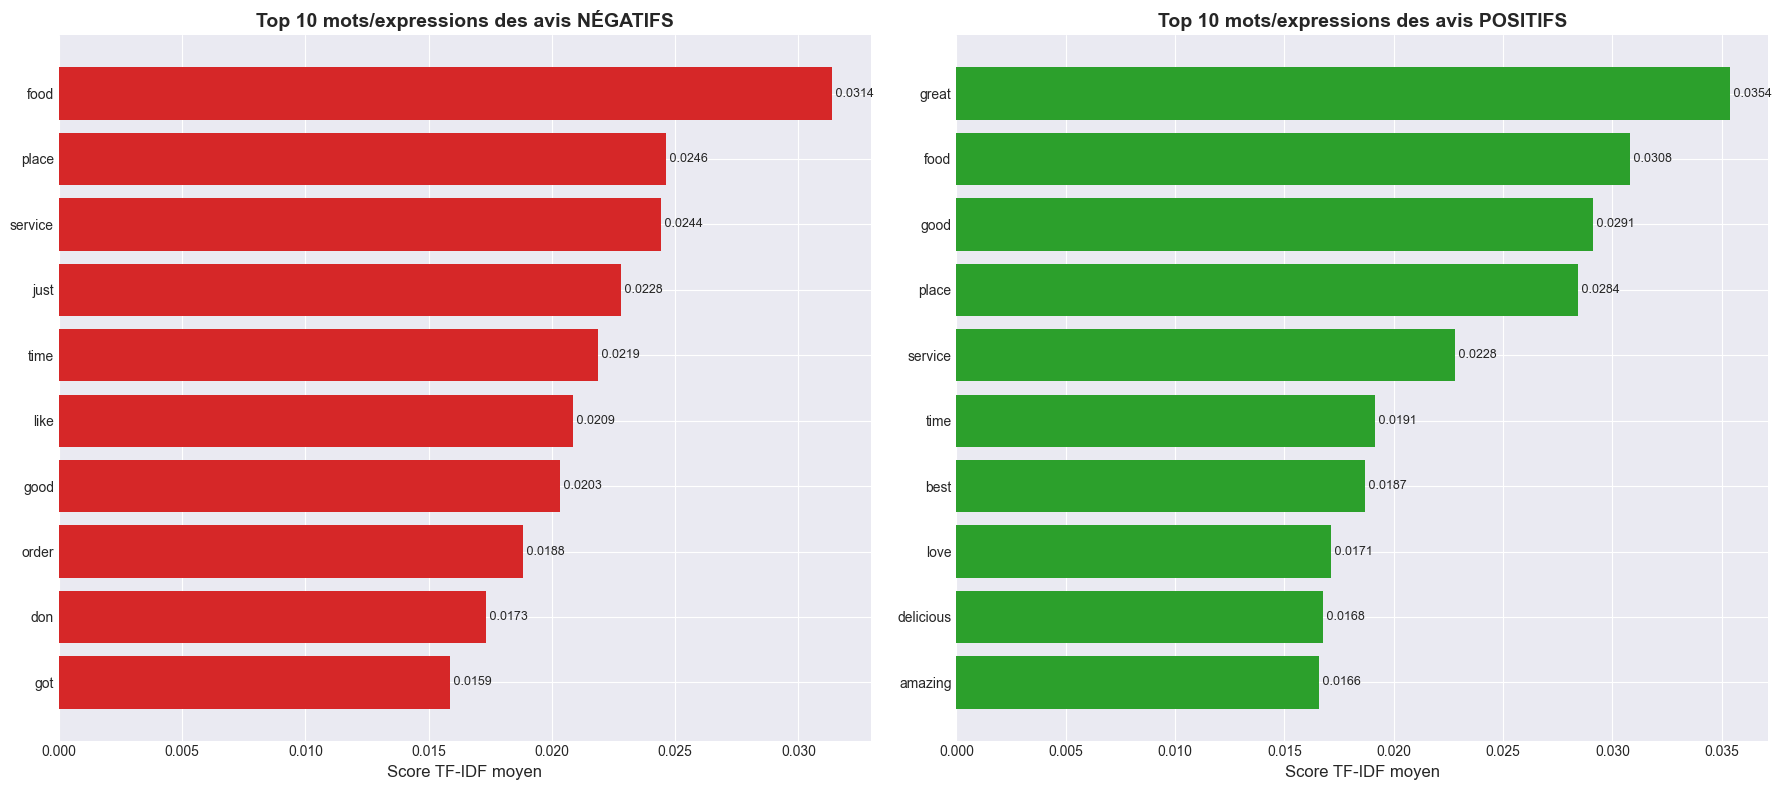

In [22]:
# Visualisation: Bar charts des top mots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top 10 mots négatifs
words_neg = [w[0] for w in top_words_neg[:10]]
scores_neg = [w[1] for w in top_words_neg[:10]]

ax1.barh(range(len(words_neg)), scores_neg, color='#d62728')
ax1.set_yticks(range(len(words_neg)))
ax1.set_yticklabels(words_neg)
ax1.invert_yaxis()
ax1.set_xlabel('Score TF-IDF moyen', fontsize=12)
ax1.set_title('Top 10 mots/expressions des avis NÉGATIFS', fontsize=14, fontweight='bold')

# Ajouter les valeurs
for i, score in enumerate(scores_neg):
    ax1.text(score, i, f' {score:.4f}', va='center', fontsize=9)

# Top 10 mots positifs
words_pos = [w[0] for w in top_words_pos[:10]]
scores_pos = [w[1] for w in top_words_pos[:10]]

ax2.barh(range(len(words_pos)), scores_pos, color='#2ca02c')
ax2.set_yticks(range(len(words_pos)))
ax2.set_yticklabels(words_pos)
ax2.invert_yaxis()
ax2.set_xlabel('Score TF-IDF moyen', fontsize=12)
ax2.set_title('Top 10 mots/expressions des avis POSITIFS', fontsize=14, fontweight='bold')

for i, score in enumerate(scores_pos):
    ax2.text(score, i, f' {score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Créer un DataFrame pour export
vocab_comparison = pd.DataFrame({
    'Négatif_mot': [w[0] for w in top_words_neg[:10]],
    'Négatif_score': [w[1] for w in top_words_neg[:10]],
    'Positif_mot': [w[0] for w in top_words_pos[:10]],
    'Positif_score': [w[1] for w in top_words_pos[:10]]
})

print("\nTableau comparatif:")
print(vocab_comparison.to_string(index=False))


Tableau comparatif:
Négatif_mot  Négatif_score Positif_mot  Positif_score
       food       0.031364       great       0.035363
      place       0.024608        food       0.030789
    service       0.024404        good       0.029126
       just       0.022821       place       0.028421
       time       0.021886     service       0.022824
       like       0.020874        time       0.019121
       good       0.020328        best       0.018703
      order       0.018812        love       0.017137
        don       0.017342   delicious       0.016754
        got       0.015861     amazing       0.016586


## 4. Proportion de notes

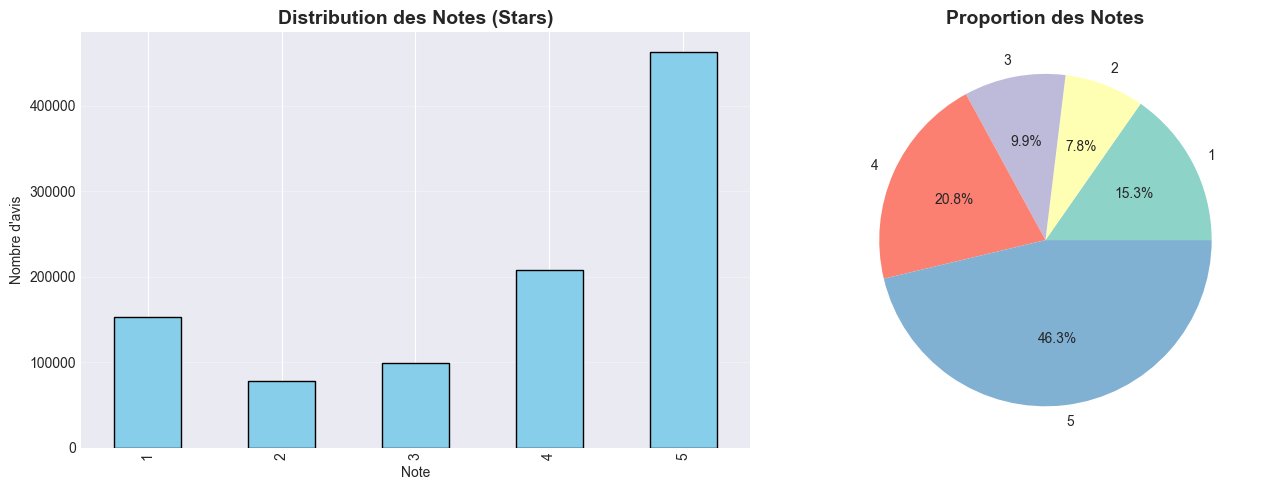


Statistiques sur les notes:
count    1000000.000000
mean           3.749501
std            1.478731
min            1.000000
25%            3.000000
50%            4.000000
75%            5.000000
max            5.000000
Name: stars, dtype: float64


In [25]:
# Distribution des stars (notes des avis)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des stars
df_reviews['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution des Notes (Stars)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre d\'avis')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
df_reviews['stars'].value_counts().sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=plt.cm.Set3.colors)
axes[1].set_title('Proportion des Notes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nStatistiques sur les notes:\n{df_reviews['stars'].describe()}")

## 5. Conclusions

### Questions à répondre:

1. **Les avis négatifs sont-ils plus longs que les avis positifs?**
   - Analyser les différences de longueur
   - Interpréter les tests statistiques
   - Hypothèses: Pourquoi?

2. **Quelle est la tendance de longueur par note?**
   - Linéaire? En U? Autre?
   - Quelle note génère les reviews les plus longues?

3. **Quels sont les mots distinctifs?**
   - Analyser les top mots négatifs vs positifs
   - Y a-t-il des patterns?
   - Insights sur le sentiment


In [ ]:
# Sauvegarder les résultats
length_by_stars.to_csv('../../data/length_by_rating_stats.csv')
vocab_comparison.to_csv('../../data/vocabulary_comparison.csv', index=False)

print("✓ Résultats sauvegardés:")
print("  - data/length_by_rating_stats.csv")
print("  - data/vocabulary_comparison.csv")